# Executive Summary
**Background:**
Volatility measures the degree of price fluctuation in a financial asset. Predicting volatility is helpful for financial institutions and traders, since it influences option pricing, risk management strategies, and responses to rapidly changing market conditions. This project investigates whether an interpretable model can predict next 30-second realised volatility and generalise to unseen assets without retraining.

**Methodology:**
Raw Optiver order book data were processed into 30-second buckets containing weighted average price, bid-ask spread, log return and realised volatility features. Six model families - Linear Regression, Lasso, Random Forest, XGBoost, MLP, and EWMA were trained on 40 anonymous stocks, and evaluated across 20 held-out anonymous stocks and 10 named technology stocks. The performance was assessed with RMSE, RMSPE and QLIKE, with QLIKE as the primary metric. 

**Findings:**
XGBoost with the long feature set performed the best (seen QLIKE: 0.179, unseen: 0.165, tech stocks: 0.073). Across models, longer-horizon volatility features had consistently better performance.

**Conclusion:**
The project shows that a global volatility model can generalise across assets when it is built around financially meaningful temporal features. The final dashboard delivers real-time volatility forecasts, alongside the model's limitations, results, and a glossary for non-technical users. 

# Aim and Background

Volatility captures the degree of uncertainty in financial markets and plays an important role in derivatives trading, option pricing, and financial risk management (Equirus, 2023). Option prices are largely driven by expectations of future volatility. As a result, if traders can predict future realised volatility more accurately than the implied volatility, they may be able to identify potential under- or over-pricing opportunities in the market.

This project investigates whether an interpretable model can predict next 30-second realised volatility and generalise to unseen assets without retraining. A 30-second forecast window was chosen since it aligns with the timescale that traders use to manage risk, while also capturing short-term volatility clustering, meaning that volatility tends to persist, without excessive microstructure noise. This report, therefore, sits at the intersection of finance and data science disciplines, with financial theory motivating the choice of model features and inferences from model results, while the data science challenge is constructing a model that generalises to other assets with no retraining. 

To achieve the project aim, two high-frequency datasets built from Optiver order book data were used. The primary dataset consists of 112 anonymous stocks, containing observed bid-ask prices. The second dataset contains 10 named technology stocks, which contain additional market information beyond quoted order book data. 

The core contribution of this project is not only the comparison of different forecasting models, but also the construction of features across multiple recent volatility horizons. This allows the report to assess whether short-term volatility forecasting is mainly driven by model complexity or by temporal features capturing volatility clustering, momentum, and session behaviour.


# Methodology

## Process
Figure 1 provides an overview of the full modelling pipeline, from data preprocessing through to generalisation testing.

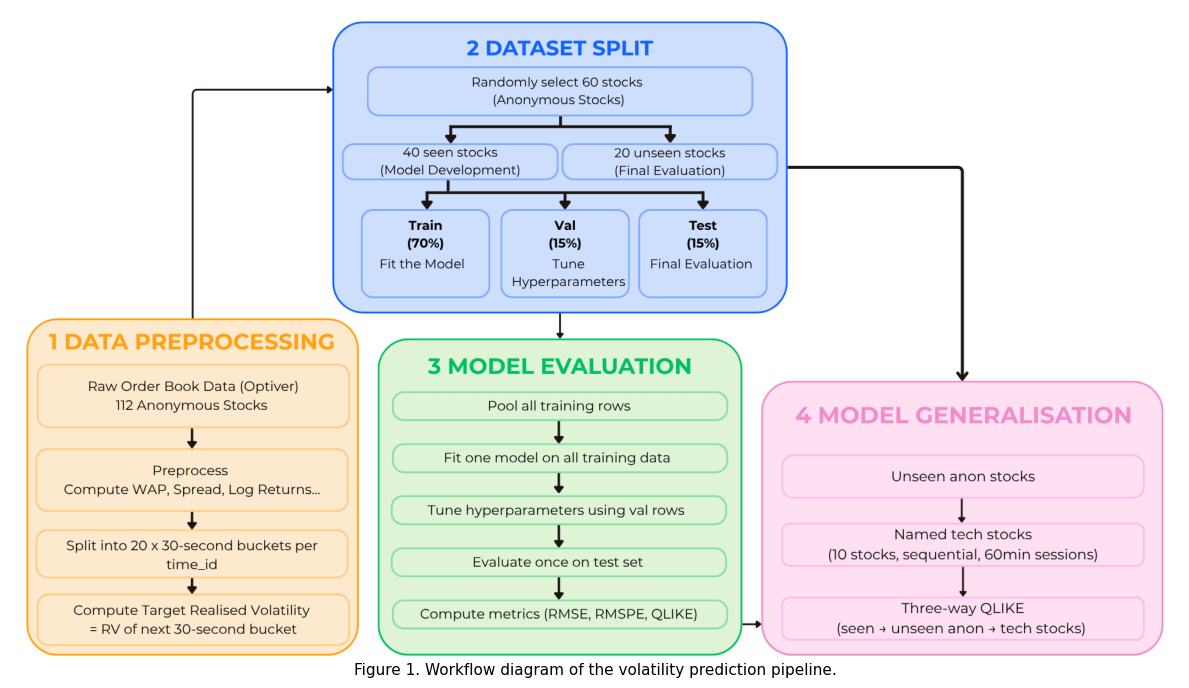

In [5]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Loading the image
img = imread("Workflow.png")   # change filename

fig, ax = plt.subplots(figsize=(12, 7))

ax.imshow(img)
ax.axis("off")

# Caption
fig.text(
    0.5, 0.02,
    "Figure 1. Workflow diagram of the volatility prediction pipeline.",
    ha='center',
    fontsize=11
)

plt.tight_layout()
plt.show()


### Data Preprocessing

The Optiver dataset consisted of 112 anonymous stock files containing high-frequency order book data, where bid and ask prices, along with volumes at two levels, were recorded whenever a change occurred. From these raw inputs, the weighted average price (WAP) and bid-ask spread were calculated. WAP represents the volume-weighted midpoint between the best bid and ask, while bid-ask spread is the relative difference between the ask and bid prices. To prevent memory constraints, each stock was stored individually as parquet files.

Missing seconds were forward-filled, carrying forward the last observed order book state, which is consistent with how order books behave. With this, WAP and bid-ask spread were recalculated to ensure consistency. The log returns were then computed from WAP within each time_id, and periods with no price movements naturally resulted in zero log returns.

Since the goal is to predict volatility over the next 30 seconds, each 10-minute window was split into 20 buckets of 30-second intervals. Within each interval, features were aggregated to summarise the price dynamics. These included the final and average WAP, average and maximum bid-ask spread, as well as measures of log returns such as their sum, standard deviation and realised volatility. The prediction target was defined as the realised volatility of the subsequent 30-second interval.

To evaluate model generalisability, a subset of 60 stocks was randomly selected from the full dataset due to computational constraints, with a seed set to 3888. These 60 stocks were then further divided into 40 ‘seen’ stocks that are used for model training and validation, and 20 ‘unseen’ stocks used for final evaluation. This separation ensures that model performance is not biased towards specific assets during training, providing a more realistic assessment of how well the model generalises to unseen stocks.


### Data Modelling 

To capture volatility dynamics across different time horizons, four feature sets of varying temporal depth were constructed: base, short, medium and long. Each feature set builds on the previous by incorporating additional temporal history. The base set contains seven features describing the current 30-second bucket: WAP, bid-ask spread, log returns and realised volatility. The short set extends this to 90 seconds by adding lagged values and rolling means from the previous two to three buckets. The medium set extends to 2.5 minutes, incorporating momentum and a volatility ratio. The long set extends to five minutes, capturing the session-level volatility regime through 10-bucket rolling statistics. The full feature list is provided in the appendix. 

Five core model families were trained and evaluated across these four feature sets. Linear Regression served as the fully interpretable baseline, with coefficients directly indicating the contribution of each feature. Lasso regression added L1 regularisation, which shrinks irrelevant feature coefficients to zero and performs automatic feature selection (Osman et al., 2017). XGBoost was a gradient boosted ensemble that built decision trees sequentially, with each tree correcting the residual error of the previous one (Wiens et.al., 2025). Random Forest was a bagged ensemble of independent decision trees trained on random subsamples of data and features, with predictions averaged across all trees to reduce variance (Salman et al., 2024). A Multi-Layer Perceptron (MLP) neural network was also included as the most flexible model, though most sensitive to distributional shifts across assets. Weighted variants of Linear Regression and XGBoost were also trained, assigning recent observations with more weight.

As a benchmark, the Exponentially Weighted Moving Average (EWMA) was included. EWMA requires no training; it predicts the next bucket’s volatility as a decaying weighted average of past values, with the decay parameter tuned on the validation set. Any model that cannot outperform the EWMA is not adding value over a simple rule-based predictor.

### Evaluation Strategy 

Model development was conducted exclusively on the 40 seen anonymous stocks. Within these, trading sessions were split at the session level (time_id), into three sets: 70% for training, 15% for hyperparameter tuning on the validation set, and 15% as a held-out test set evaluation. Since time IDs are non-sequential and independent, splitting at the session level rather than the stock level ensures all 40 stocks appear across all three sets, forcing the model to learn patterns that hold across stocks rather than memorising any particular one. 

All models were trained on the training set, and hyperparameters were tuned using the validation set via randomised search with a predefined split, ensuring the test set was never used during development. Hyperparameters for XGBoost, Random Forest and MLP are reported in the appendix. Final model performance was then evaluated on the test set across three metrics: Root Mean Squared Error (RMSE), which measures raw prediction error in the same units as realised volatility; Root Mean Squared Percentage Error (RMSPE), which measures relative prediction error as a percentage; and QLIKE, the industry standard loss function for volatility forecasting that penalises underestimation more heavily than overestimation which is used as the main metric.  

Once models were finalised on the seen stocks, all models were applied, with no retraining, to the 20 unseen anonymous stocks. These stocks were locked away entirely during development and serve as the first test of generalisation. The same models were then applied to the 10 named tech stocks from the second dataset, acting as the primary generalisation test. 

This three-stage framework, seen stocks, unseen stocks, named tech stocks, provides a rigorous and progressively harder test of whether the models have learned universal volatility structure rather than patterns specific to the stocks they were trained on. 


## Justification

Several methodological decisions were made to ensure the problem was formulated in a way that is meaningful from both a data science and finance perspective. Thirty-second buckets were chosen because they align with the short time horizon at which market makers actively manage risk, while still containing enough observations to produce stable realised volatility estimates. Andersen and Bollerslev (1998) show that high-frequency returns provide more accurate volatility measurements than lower-frequency alternatives, supporting the use of short aggregation windows. Similarly, missing seconds were forward-filled rather than interpolated. Since the order book only updates when a new order arrives or an existing order is cancelled, the most recent observation remains the best representation of the market state until another update occurs (O'Hara, 1995).

QLIKE was used as the primary evaluation metric because it better reflects the practical consequences of volatility forecasting errors (Patton, 2011). Underestimating volatility can lead a trader to sell options too cheaply and take on additional risk, whereas overestimating volatility is generally less costly. RMSE and RMSPE were also reported to provide additional measures of model performance, but QLIKE was considered the most relevant metric from a trading perspective.
Finally, the construction of the base, short, medium and long feature sets was motivated by the idea that volatility is not driven solely by the most recent observation. Corsi (2009) shows that volatility exhibits persistence across multiple time horizons, with recent and longer-term volatility both contributing to future behaviour. By progressively incorporating additional temporal information, the feature sets allow us to assess whether broader volatility context improves forecasting performance and generalisability across assets.




# Results

## Findings
### Seen Stock Performance 


In [6]:
import json
import pandas as pd
from IPython.display import display, HTML

# Load results
with open("dashboard_outputs/results.json") as f:
    results = json.load(f)

# Table
rows = []
for horizon in ['Base', 'Short', 'Medium', 'Long']:
    n_features = {'Base': 7, 'Short': 15, 'Medium': 24, 'Long': 32}[horizon]
    rows.append({
        'Horizon':        horizon,
        'Features':       n_features,
        'XGBoost QLIKE':  results[f'XGB {horizon}']['qlike'],
        'Linear QLIKE':   results[f'LR {horizon}']['qlike'],
        'Lasso QLIKE':    results[f'Lasso {horizon}']['qlike'],
        'RF QLIKE':       results[f'RF {horizon}']['qlike'],
        'MLP QLIKE':      results[f'MLP {horizon}']['qlike'],
    })

rows.append({
    'Horizon':        'EWMA',
    'Features':       '—',
    'XGBoost QLIKE':  results['EWMA']['qlike'],
    'Linear QLIKE':   results['EWMA']['qlike'],
    'Lasso QLIKE':    results['EWMA']['qlike'],
    'RF QLIKE':       results['EWMA']['qlike'],
    'MLP QLIKE':      results['EWMA']['qlike'],
})

horizon_df = pd.DataFrame(rows)

display(
    horizon_df.style.format({
        'XGBoost QLIKE': '{:.6f}',
        'Linear QLIKE':  '{:.6f}',
        'Lasso QLIKE':   '{:.6f}',
        'RF QLIKE':      '{:.6f}',
        'MLP QLIKE':     '{:.6f}',
    })
)
display(HTML(
    "<div style='text-align:center; font-size:10pt; margin-top:8px;'>"
    "Table 1. QLIKE comparison across feature horizons and model families."
    "</div>"
))

,Horizon,Features,XGBoost QLIKE,Linear QLIKE,Lasso QLIKE,RF QLIKE,MLP QLIKE
0,Base,7,0.195131,0.217463,0.211676,0.213748,0.205506
1,Short,15,0.183397,0.190087,0.192527,0.209477,0.192633
2,Medium,24,0.180393,0.184700,0.187061,0.207271,0.320451
3,Long,32,0.178809,0.181288,0.183051,0.201957,0.182709
4,EWMA,—,0.270585,0.270585,0.270585,0.270585,0.270585


XGBoost with the long feature set achieved the lowest QLIKE score of 0.179. This finding might be because gradient boosting algorithms are able to model complex nonlinear relationships that exist in high-frequency financial data. The long feature set achieved the lowest QLIKE across all model families, confirming that longer temporal context improves forecasting. Almost all models outperformed the EWMA benchmark (QLIKE: 0.271), with MLP Medium being the only exception, likely due to an outlier from hyperparameter tuning instability.

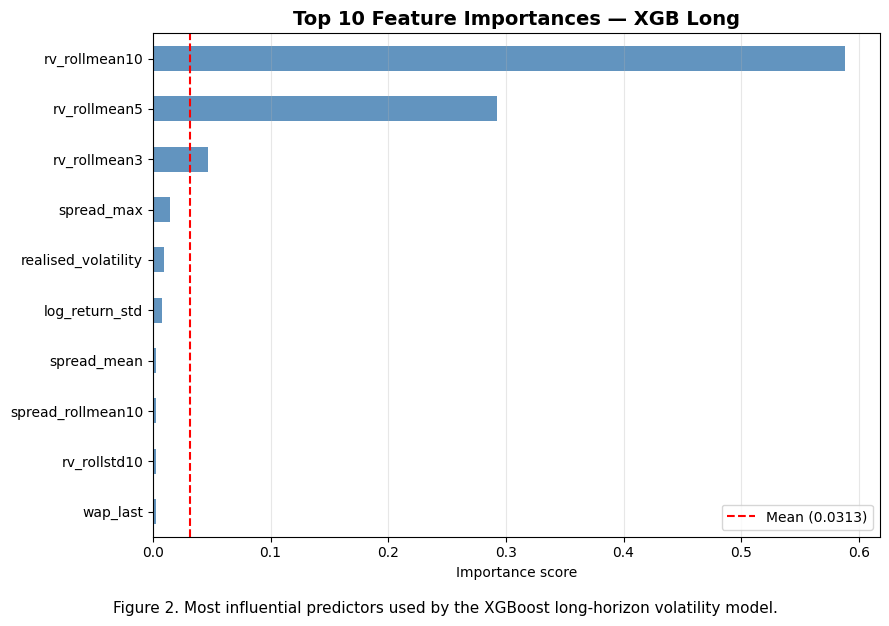

In [8]:
# Load model and features
import joblib
xgb_long_model = joblib.load("models/xgb_long_model.pkl")

with open("dashboard_outputs/features_long.json") as f:
    features_long = json.load(f)

xgb_importances = pd.Series(
    xgb_long_model.feature_importances_,
    index=features_long
).sort_values(ascending=False)

# Use top 10
top_10_importances = xgb_importances.head(10)
fig, ax = plt.subplots(figsize=(9, 6))
top_10_importances.sort_values().plot(
    kind='barh',
    ax=ax,
    color='steelblue',
    alpha=0.85
)
ax.axvline(
    xgb_importances.mean(),
    color='red',
    linestyle='--',
    label=f'Mean ({xgb_importances.mean():.4f})'
)
ax.set_title(
    'Top 10 Feature Importances — XGB Long',
    fontweight='bold',
    fontsize=14
)
ax.set_xlabel('Importance score')
ax.set_ylabel('')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    'feature_importance_top10_xgb_long.png',
    dpi=150,
    bbox_inches='tight'
)

fig.text(
    0.5, -0.03,
    "Figure 2. Most influential predictors used by the XGBoost long-horizon volatility model.",
    ha='center',
    fontsize=11
)
plt.tight_layout()
plt.show()

As shown in Figure 2, rolling mean volatility features dominated performance, explaining the high performance of the long models. The domination of the rolling RV features suggests that the feature selection had a greater impact than the model selection, with all model types (linear, neural network, boosting) having similar performance and spread. In addition, the consistent boxplot distributions suggest that model performance was reasonably stable across the various stocks and did not depend on a small number of highly predictable stocks. Additionally, XGBoost provides interpretability through feature importance scores, allowing traders to understand which feature is contributing the most to the prediction. 

Results indicate the need for carefully designed feature engineering, as even relatively interpretable models were able to obtain competitive forecasting accuracy with well-processed financial features.


### Generalisation to unseen stocks 


All models maintained strong performance, with Weighted XGBoost and XGBoost long achieving the best results (QLIKE 0.165). Every model performed slightly better on the unseen stocks than the seen ones, suggesting that the models learned the broader volatility behaviour across many stocks, rather than learning individual stock patterns.




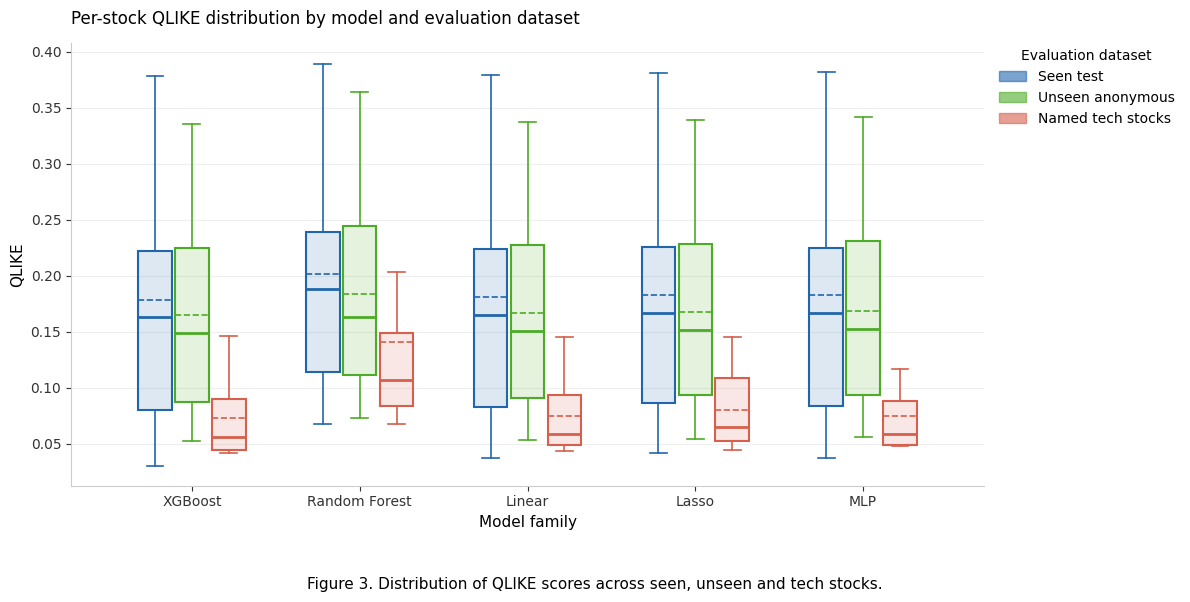

In [9]:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

EPS = 1e-8

CORE_LONG_MODELS = ["XGB Long", "RF Long", "LR Long", "Lasso Long", "MLP Long"]
CORE_FAMILY_LABELS = {
    "XGB Long":   "XGBoost",
    "RF Long":    "Random Forest",
    "LR Long":    "Linear",
    "Lasso Long": "Lasso",
    "MLP Long":   "MLP",
}

def should_use_log_axis(values: pd.Series) -> bool:
    vals = pd.to_numeric(values, errors="coerce")
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if len(vals) < 2:
        return False
    return bool(vals.max() / max(vals.min(), EPS) > 80)

# Load data

def load_per_stock_long_results() -> pd.DataFrame:
    for path in [
        "dashboard_outputs/per_stock_long_results.csv",
        "per_stock_long_results.csv",
        "dashboard_outputs/seen_per_stock_long_results.csv",
    ]:
        try:
            df = pd.read_csv(path)
            break
        except FileNotFoundError:
            continue
    else:
        print("WARNING: per_stock_long_results.csv not found.")
        return pd.DataFrame()

    required = {"Split", "Model Group", "Model", "stock_id", "RMSE", "RMSPE", "QLIKE"}
    if not required.issubset(df.columns):
        print(f"WARNING: missing columns: {required - set(df.columns)}")
        return pd.DataFrame()

    for col in ["RMSE", "RMSPE", "QLIKE", "n_rows"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df["Model"].isin(CORE_LONG_MODELS)].copy()
    df["Model Group"] = df["Model Group"].replace({
        "Normal Long": "Normal long models",
        "Standard":    "Normal long models",
    })
    df["Split"] = df["Split"].replace({
        "Seen":   "Seen test",
        "Unseen": "Unseen anonymous",
    })
    return df


def load_tech_per_stock_results() -> pd.DataFrame:
    for path in [
        "dashboard_outputs/tech_per_stock_all_models.csv",
        "tech_per_stock_all_models.csv",
        "models/tech_per_stock_all_models.csv",
    ]:
        try:
            df = pd.read_csv(path)
            break
        except FileNotFoundError:
            continue
    else:
        print("WARNING: tech_per_stock_all_models.csv not found.")
        return pd.DataFrame()

    rename = {"model": "Model", "stock": "stock_id",
              "rmse": "RMSE", "rmspe": "RMSPE", "qlike": "QLIKE"}
    df = df.rename(columns=rename).copy()

    required = {"stock_id", "Model", "RMSE", "RMSPE", "QLIKE"}
    if not required.issubset(df.columns):
        print(f"WARNING: missing columns: {required - set(df.columns)}")
        return pd.DataFrame()

    for col in ["RMSE", "RMSPE", "QLIKE", "n_rows"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df["Model"].isin(CORE_LONG_MODELS)].copy()
    df["Dataset"] = "Named tech stocks"
    return df


PER_STOCK_LONG_RESULTS = load_per_stock_long_results()
TECH_PER_STOCK_RESULTS = load_tech_per_stock_results()

def generalisability_distribution_df(metric: str = "QLIKE") -> pd.DataFrame:
    rows = []

    if not PER_STOCK_LONG_RESULTS.empty:
        d = PER_STOCK_LONG_RESULTS[
            PER_STOCK_LONG_RESULTS["Model"].isin(CORE_LONG_MODELS)
        ].copy()
        if "Model Group" in d.columns:
            d = d[d["Model Group"].astype(str).eq("Normal long models")].copy()
        keep_cols = [c for c in ["Split", "Model", "stock_id", "n_rows", metric] if c in d.columns]
        d = d[keep_cols].copy()
        d = d.rename(columns={"Split": "Dataset", metric: "Value"})
        rows.append(d)

    if not TECH_PER_STOCK_RESULTS.empty:
        t = TECH_PER_STOCK_RESULTS[TECH_PER_STOCK_RESULTS["Model"].isin(CORE_LONG_MODELS)].copy()
        keep_cols = [c for c in ["Dataset", "Model", "stock_id", "n_rows", metric] if c in t.columns]
        t = t[keep_cols].copy().rename(columns={metric: "Value"})
        rows.append(t)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out["Value"]  = pd.to_numeric(out["Value"], errors="coerce")
    out = out.dropna(subset=["Value"])
    out = out[out["Model"].isin(CORE_LONG_MODELS)].copy()
    out["Family"] = out["Model"].astype(str).map(CORE_FAMILY_LABELS)
    out["Dataset"] = out["Dataset"].replace({
        "Seen":   "Seen test",
        "Unseen": "Unseen anonymous",
    })
    out["Dataset"] = pd.Categorical(
        out["Dataset"],
        categories=["Seen test", "Unseen anonymous", "Named tech stocks"],
        ordered=True,
    )
    out["Model"]  = pd.Categorical(out["Model"],  categories=CORE_LONG_MODELS, ordered=True)
    out["Family"] = pd.Categorical(
        out["Family"],
        categories=[CORE_FAMILY_LABELS[m] for m in CORE_LONG_MODELS],
        ordered=True,
    )
    return out.sort_values(["Dataset", "Model"])


def plot_generalisability_box(metric: str = "QLIKE") -> None:
    d = generalisability_distribution_df(metric)

    if d.empty:
        print("No data available — check CSV files.")
        return

    d["Value"]   = pd.to_numeric(d["Value"],   errors="coerce")
    d["Family"]  = d["Family"].astype(str)
    d["Dataset"] = d["Dataset"].astype(str)
    d = d.dropna(subset=["Value"])

    dataset_order  = ["Seen test", "Unseen anonymous", "Named tech stocks"]
    family_order   = [CORE_FAMILY_LABELS[m] for m in CORE_LONG_MODELS]
    n_families     = len(family_order)

    dataset_colors = {
        "Seen test":         "#2166ac",   # steel blue
        "Unseen anonymous":  "#4dac26",   # muted green
        "Named tech stocks": "#d6604d",   # terracotta
    }

    box_width = 0.20
    offsets   = [-0.22, 0.00, 0.22]
    x_centers = np.arange(n_families)

    fig, ax = plt.subplots(figsize=(12, 5.5), facecolor="white")
    ax.set_facecolor("white")

    for di, dataset in enumerate(dataset_order):
        color = dataset_colors[dataset]
        for fi, family in enumerate(family_order):
            vals = d.loc[
                d["Dataset"].eq(dataset) & d["Family"].eq(family), "Value"
            ].dropna().values

            if len(vals) == 0:
                continue

            pos = x_centers[fi] + offsets[di]
            ax.boxplot(
                vals,
                positions=[pos],
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                showmeans=True,
                meanline=True,
                boxprops=dict(facecolor=color + "26", color=color, linewidth=1.5),
                medianprops=dict(color=color, linewidth=2.0),
                meanprops=dict(color=color, linewidth=1.2, linestyle="--"),
                whiskerprops=dict(color=color, linewidth=1.2),
                capprops=dict(color=color, linewidth=1.2),
            )

    ax.set_xticks(x_centers)
    ax.set_xticklabels(family_order, fontsize=11)
    ax.set_xlabel("Model family", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(
        f"Per-stock {metric} distribution by model and evaluation dataset",
        fontsize=12, fontweight="normal", pad=14, loc="left",
    )

    if should_use_log_axis(d["Value"]):
        ax.set_yscale("log")

    ax.yaxis.grid(True, color="#eeeeee", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(axis="both", labelsize=10, colors="#333333")

    legend_handles = [
        mpatches.Patch(facecolor=dataset_colors[ds], edgecolor=dataset_colors[ds],
                       alpha=0.6, label=ds)
        for ds in dataset_order
    ]
    ax.legend(
        handles=legend_handles,
        title="Evaluation dataset",
        title_fontsize=10,
        fontsize=10,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
    )

    plt.tight_layout()
    plt.savefig(
        f"generalisability_box_{metric.lower()}.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )


metric = "QLIKE"   
plot_generalisability_box(metric)

plt.figtext(
    0.5, -0.08,
    "Figure 3. Distribution of QLIKE scores across seen, unseen and tech stocks.",
    ha='center',
    fontsize=11
)

plt.tight_layout()
plt.show()

Similar to the seen set, the longer feature set achieved the lowest QLIKE across all models. Per-stock QLIKE distributions showed large standard deviations and right skewness, which is expected in real financial markets, since some stocks are inherently more unstable and unpredictable than others. The skewness suggests that most stocks were predicted well, with a smaller subset with higher errors. 

### Generalisation to Tech Stocks

All models generalised successfully, with every model achieving a lower QLIKE on the tech stocks than on the anonymous stocks, as seen in Figure 3. Similar to the anonymous set, XGBoost long achieved the best performance (QLIKE 0.0727), likely due to its capabilities to capture small non-linearities within the rolling RV features while preserving the dominant temporal signal.

The improvement in tech stocks also shows the smoother nature of the large and highly liquid tech stocks such as Apple and Microsoft, which are easier to predict. Moreover, the hourly structure of the tech stocks reduces the microstructure noise compared to the anonymous dataset, contributing to stable predictions.This may also explain the reason behind the smaller standard deviation of the tech stocks. 

Overall, the results provide strong evidence that the models generalised well across both unseen and tech stocks, rather than simply overfitting the training data. This suggests that short-term volatility dynamics share common characteristics across different stocks. This supports the use of a global model, rather than multiple models for different types of stocks. 



## Deployment

After model evaluation, the final results were deployed in an interactive dashboard. The dashboard was designed for traders, but also included explanatory material for users outside of the finance discipline. It contained a summary page, model results page, workflow page, generalisability page, limitations page, glossary and forecasting page.

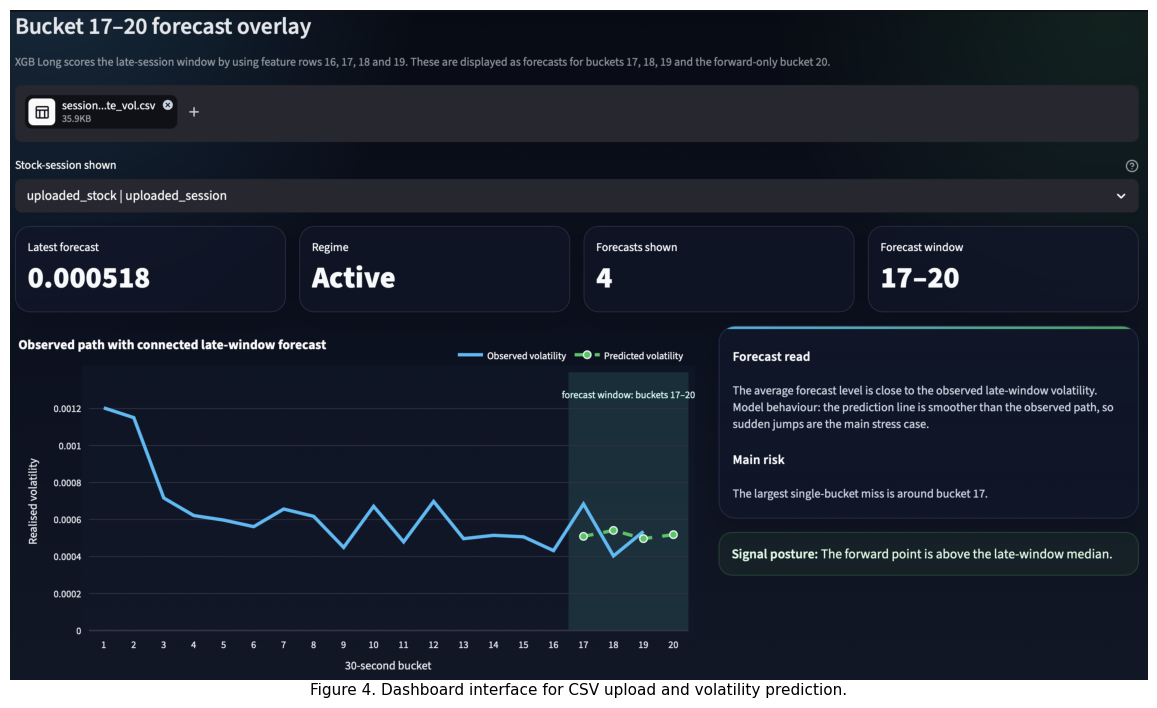

In [10]:
from matplotlib.image import imread

# Load image

img = imread("Dashboard.png")   # change filename

# ── Create figure ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

ax.imshow(img)
ax.axis("off")

# ── Caption ────────────────────────────────────────────────
fig.text(
    0.5, 0.0,
    "Figure 4. Dashboard interface for CSV upload and volatility prediction.",
    ha='center',
    fontsize=11
)

plt.tight_layout()
plt.show()

The forecasting page allows a user to upload order book data and deploy the XGBoost Long model, which was trained to obtain a next 30-second realised volatility prediction. To make the output more interpretable, the dashboard also displays recent realised volatility and recent model predictions. This allows the user to judge whether the model has recently been reliable before relying on the newest forecast. The uploaded file, however, is restricted to CSV format with flexible column names, and performs best when structured as a 10-minute order book format, as models were trained under these circumstances. 

The dashboard also communicates the project’s limitations. This was important because a volatility model should not be presented as a definitive prediction. Instead, it is a decision-support tool that gives traders an evidence-based estimate of near-term risk.


# Discussion and Conclusion

XGBoost long was the model best suited to the goal of this report, as it performed best on all metrics, generalised well on unseen and known tech stocks, and is appropriately interpretable.  The gap between XGBoost Long and Linear Regression Long was quite small, suggesting that feature engineering was the main driver of performance rather than model complexity. This is a key result of the project, as it shows that the constructed volatility horizons were central to the model’s performance.

This finding is important from both a data science and finance perspective. From a data science perspective, it suggests that the main value came from representing the problem properly, rather than only from applying more complex algorithms. From a finance perspective, it makes the model more interpretable because the dominant signals can be linked to volatility clustering, momentum and liquidity conditions. 

One key limitation was not having time-series cross-validation. Since only one train-validation-test split was used, the results may vary depending on which sessions end up in each group. Additionally, only 40 of the 112 available stocks were used for training. Both of these were due to computational constraints. The fact that the time_ids in the anonymous stock dataset are not sequential also meant that proper sequential splitting was not possible.

There are also important finance-specific limitations. The model assumes that relationships learned from historical order book behaviour remain stable, but financial markets can shift rapidly across different regimes, like an economic boom or recession. Moreover, the analysis does not account for transaction costs or whether a forecast improvement would be large enough to support a profitable trading strategy after costs. Therefore, the model should be interpreted as a short-term risk signal rather than a complete trading system.

Strong technology-stock performance is promising, but should be interpreted carefully as it might partly reflect differences in scale or distribution rather than pure improvement, as anonymous stocks had 10-minute sessions, while the technology stocks had 60-minute sessions. It is also worth noting that the anonymous training dataset may have contained some of the named technology stocks used for external testing. If so, part of the strong technology-stock performance could reflect some familiarity with those stocks rather than true generalisation.

For future work, the next step would be to train on all 112 stocks and implement time-series cross-validation where sequential structure is available (Geeksforgeeks, 2025). This would give a more reliable picture of out-of-sample performance. In addition, deep learning models such as LSTMs and temporal convolutional networks could also be explored as alternatives to manually engineering lag features (ricardocolindres, 2023). From a finance perspective, future work could incorporate order-flow imbalance, trade volume, and testing across different market regimes to assess whether the forecasts remain useful under realistic trading conditions. The dashboard could also be improved through stronger input validation and uncertainty intervals.

Overall, this project shows that a single global model trained once on anonymous stocks can generalise meaningfully to stocks it has never seen. The results provide strong evidence that the models learned broadly generalisable volatility dynamics, though it should be noted that evaluation was limited to stock market data and a specific data format, so the model cannot be considered universally generalisable. The dashboard translates the model into a format that is usable and interpretable for short-term volatility forecasting. While constraints around computational resources, dataset structure, market microstructure noise and trading applicability remain, the core finding provides a useful starting point for future work in this area.


# Student Contribution 

Scarlett and Pratyaksh focused on code, evaluation framework, preprocessing and model building. Callista handled meeting minutes, the workflow diagram, made observations and contributed meaningfully to the methodology and discussion section of the report. Kian developed the deployment of the project and contributed to writing the results section of the report, along with editing. Max did background research and contributed meaningfully to the introduction and conclusion of this report. Carson (Zheng) contributed to the lasso regression model building, along with writing the results section of the report. 

**AI Acknowledgement:**

We acknowledge the use of Artificial Intelligence platforms such as Claude (https://claude.ai/) and ChatGPT (https://chatgpt.com) as a tool to enhance hyperparameter tuning, evaluation logic, and to edit the final report. All work in this report was completed by the listed authors, and AI was simply used as a tool to check over and edit completed work. 


# References

Andersen, T.G. and Bollerslev, T. (1998). Answering the skeptics: Yes, standard volatility models do provide accurate forecasts. International Economic Review, 39(4), 885–905.

Corsi, F. (2009). A simple approximate long-memory model of realized volatility. Journal of Financial Econometrics, 7(2), 174–196.

Equirus. (2023). Volatility: What it is, why it matters, types & key drivers. Equirus.com. https://www.equirus.com/glossary/volatility

Geeksforgeeks. (2025, July 23). Time Series Cross-Validation. Geeksforgeeks.org.
https://www.geeksforgeeks.org/machine-learning/time-series- cross-validation/

ricardocolindres. (2023, June 18). LSTM vs TCN for Time Series Analysis Comparison. Kaggle.com; Kaggle.
https://www.kaggle.com/code/ricardocolindres/lstm-vs-tcn-for-time-series-analysis-comparison

O'Hara, M. (1995). Market Microstructure Theory. Blackwell Publishers. [cited via Stoll, H. (1995) review, The Review of Financial Studies, 8(4), 1235–1238]

Optiver (2021). Optiver Realized Volatility Prediction. Kaggle. Available at: https://www.kaggle.com/competitions/optiver-realized-volatility-prediction

Osman, H., Ghafari, M., & Nierstrasz, O. (2017). Automatic feature selection by regularization to improve bug prediction accuracy. In Proceedings of MALTESQUE 2017. https://doi.org/10.1109/MALTESQUE.2017.7882013
 
Patton, A, J. (2011). Volatility forecast comparison using imperfect volatility proxies. Science Direct. https://www.sciencedirect.com/science/article/pii/S030440761000076X 

Salman, H., Kalakech, A., & Steiti, A. (2024). Random forest algorithm overview. Babylonian Journal of Machine Learning, 2024, 69–79. https://doi.org/10.58496/BJML/2024/007

Wiens, M., Verone-Boyle, A., Henscheid, N., Podichetty, J. T., & Burton, J. (2025). A Tutorial and Use Case Example of the eXtreme Gradient Boosting (XGBoost) Artificial Intelligence Algorithm for Drug Development Applications. Clinical and translational science, 18(3), e70172. https://doi.org/10.1111/cts.70172

# Appendix

## Github

Link: https://github.sydney.edu.au/scha8986/Data3888_Capstone.git

## Feature List

In [54]:
import json
import pandas as pd
from IPython.display import display, HTML

with open("dashboard_outputs/features_all_horizons.json") as f:
    fl = json.load(f)

base_features = fl['base']
short_f  = [f for f in fl['short']  if f not in fl['base']]
medium_f = [f for f in fl['medium'] if f not in fl['short']]
long_f   = [f for f in fl['long']   if f not in fl['medium']]

max_len = max(len(base_features), len(short_f), len(medium_f), len(long_f))

def pad(lst): return lst + [''] * (max_len - len(lst))

feature_df = pd.DataFrame({
    'Base (7)':             pad(base_features),
    'Short additions (8)':  pad(short_f),
    'Medium additions (9)': pad(medium_f),
    'Long additions (8)':   pad(long_f),
})

display(feature_df.style.hide(axis='index'))
display(HTML(
    "<div style='text-align:center; font-size:11pt; margin-top:8px;'>"
    "Table A1. Full feature list by horizon. Each horizon is cumulative — "
    "Short includes Base + Short additions, Medium includes Base + Short + Medium additions, and so on."
    "</div>"
))

Base (7),Short additions (8),Medium additions (9),Long additions (8)
wap_mean,rv_lag2,rv_lag5,rv_lag10
wap_last,rv_lag3,spread_lag5,spread_lag10
spread_mean,spread_lag2,logret_lag5,rv_momentum10
spread_max,spread_lag3,rv_momentum5,rv_rollmean10
log_return_sum,logret_lag2,rv_rollmean5,rv_rollstd10
log_return_std,rv_delta,rv_rollstd5,spread_rollmean10
realised_volatility,rv_rollmean3,spread_rollmean5,rv_ratio10
,spread_rollmean3,rv_ratio5,rv_above_mean10
,,rv_above_mean5,


## Results across all models

In [55]:
import json
import pandas as pd
from IPython.display import display, HTML

with open("dashboard_outputs/results.json") as f:
    results = json.load(f)

models = [
    'LR Base', 'LR Short', 'LR Medium', 'LR Long',
    'Lasso Base', 'Lasso Short', 'Lasso Medium', 'Lasso Long',
    'XGB Base', 'XGB Short', 'XGB Medium', 'XGB Long',
    'RF Base', 'RF Short', 'RF Medium', 'RF Long',
    'MLP Base', 'MLP Short', 'MLP Medium', 'MLP Long',
    'WLR Base', 'WLR Short', 'WLR Medium', 'WLR Long',
    'WXGB Base', 'WXGB Short', 'WXGB Medium', 'WXGB Long',
    'EWMA',
]

rows = []
for m in models:
    if m not in results:
        continue
    rows.append({
        'Model':  m,
        'RMSE':   results[m]['rmse'],
        'RMSPE':  results[m]['rmspe'],
        'QLIKE':  results[m]['qlike'],
    })

results_df = pd.DataFrame(rows)

display(
    results_df.style
    .format({
        'RMSE':  '{:.6f}',
        'RMSPE': '{:.4f}',
        'QLIKE': '{:.6f}',
    })
    .hide(axis='index')
)
display(HTML(
    "<div style='text-align:center; font-size:11pt; margin-top:8px;'>"
    "Table A2. Full results across all models and horizons (seen test set). "
    "RMSE, RMSPE and QLIKE reported."
    "</div>"
))

Model,RMSE,RMSPE,QLIKE
LR Base,0.000659,12.8148,0.217463
LR Short,0.000606,11.3633,0.190087
LR Medium,0.000584,11.0711,0.184700
LR Long,0.000558,10.7478,0.181288
Lasso Base,0.000650,11.7501,0.211676
Lasso Short,0.000608,11.2226,0.192527
Lasso Medium,0.000586,10.9814,0.187061
Lasso Long,0.000559,10.8279,0.183051
XGB Base,0.000633,11.8539,0.195131
XGB Short,0.000598,11.5592,0.183397


## Hyper Parameters tuned. 

In [56]:
import pandas as pd
from IPython.display import display, HTML

# XGB
xgb_params = pd.DataFrame([
    {'Parameter': 'n_estimators',      'Search Range': '100 – 600'},
    {'Parameter': 'max_depth',         'Search Range': '3 – 7'},
    {'Parameter': 'learning_rate',     'Search Range': '0.01 – 0.30'},
    {'Parameter': 'subsample',         'Search Range': '0.6 – 1.0'},
    {'Parameter': 'colsample_bytree',  'Search Range': '0.5 – 1.0'},
    {'Parameter': 'min_child_weight',  'Search Range': '1 – 9'},
    {'Parameter': 'reg_alpha',         'Search Range': '0 – 2'},
    {'Parameter': 'reg_lambda',        'Search Range': '1 – 6'},
])

# RF
rf_params = pd.DataFrame([
    {'Parameter': 'n_estimators',     'Search Range': '20 – 100'},
    {'Parameter': 'max_depth',        'Search Range': '3 – 7'},
    {'Parameter': 'min_samples_leaf', 'Search Range': '5 – 29'},
    {'Parameter': 'max_features',     'Search Range': '0.3 – 0.8'},
])

# MLP
mlp_params = pd.DataFrame([
    {'Parameter': 'hidden_layer_sizes', 'Search Range': '(64,32), (128,64), (64,), (32,16), (128,64,32)'},
    {'Parameter': 'alpha',              'Search Range': '1e-5 – 1e-2'},
    {'Parameter': 'learning_rate_init', 'Search Range': '1e-4 – 5e-3'},
])

for df, label, caption in [
    (xgb_params, 'XGBoost',       'Table A3. XGBoost hyperparameter search space.'),
    (rf_params,  'Random Forest', 'Table A4. Random Forest hyperparameter search space.'),
    (mlp_params, 'MLP',           'Table A5. MLP hyperparameter search space.'),
]:
    display(HTML(f"<h4 style='margin-bottom:4px'>{label}</h4>"))
    display(df.style.hide(axis='index'))
    display(HTML(
        f"<div style='text-align:center; font-size:11pt; margin-top:8px; margin-bottom:20px;'>"
        f"{caption}</div>"
    ))

Parameter,Search Range
n_estimators,100 – 600
max_depth,3 – 7
learning_rate,0.01 – 0.30
subsample,0.6 – 1.0
colsample_bytree,0.5 – 1.0
min_child_weight,1 – 9
reg_alpha,0 – 2
reg_lambda,1 – 6


Parameter,Search Range
n_estimators,20 – 100
max_depth,3 – 7
min_samples_leaf,5 – 29
max_features,0.3 – 0.8


Parameter,Search Range
hidden_layer_sizes,"(64,32), (128,64), (64,), (32,16), (128,64,32)"
alpha,1e-5 – 1e-2
learning_rate_init,1e-4 – 5e-3
